# Decoding Market Spillover via Multi-Relational Graph Transformers and RoPE

**STAT 3106 Project Prototype**  
**Team:** Weihang Huang (wh2607), Astrid Teo (st3750)  
**Instructor:** Prof. Bianca Dumitrascu

---

## Table of Contents
1. [Background & Motivation](#1-background)
2. [Dataset Loading & EDA](#2-data)
3. [Feature Engineering & Graph Construction](#3-features)
4. [Baseline Model: LSTM](#4-lstm)
5. [WIRE: Wavelet-Induced Rotary Encodings](#5-wire)
6. [Graph Transformer with WIRE](#6-transformer)
7. [Training & Evaluation](#7-eval)
8. [Next Steps](#8-next)

<a id="1-background"></a>
## 1. Background & Motivation

### Why This Problem Matters
Financial markets are interconnected systems where shocks propagate across assets through fundamental business relationships — supply chains, sector co-membership, and institutional co-ownership. Traditional time-series models (e.g., LSTM, GRU) treat each stock independently, ignoring these cross-sectional spillover channels. Graph Neural Networks (GNNs) address this by modeling stocks as nodes in a graph, but most existing approaches (including the Stanford CS224W Differential Graph Transformer) infer edges *solely* from statistical price correlations (Pearson, Mutual Information). This makes them vulnerable to **spurious correlations** — two stocks may move together temporarily without sharing any fundamental linkage.

### Prior Work
- **Differential Graph Transformer (DGT)** (Li, Stanford CS224W): Constructs a fully-connected graph over S&P 500 stocks, using Pearson correlation of historical returns as edge weights. An LSTM encodes temporal features, which are then refined by a Graph Transformer. While effective, the purely statistical edge construction conflates true spillover with coincidental co-movement.
- **Rotary Position Encodings (RoPE)** (Su et al., 2024): Originally designed for sequence transformers in LLMs, RoPE decomposes token embeddings into 2D blocks and applies position-dependent rotations. This enables the attention mechanism to implicitly encode relative position without explicit bias terms.
- **WIRE: Wavelet-Induced Rotary Encodings** (Reid et al., 2024): Generalizes RoPE to graph-structured data by using Laplacian eigenvectors as positional coordinates. WIRE rotates query/key vectors by angles derived from graph spectral features, injecting topological structure directly into the attention computation. Crucially, WIRE is compatible with linear attention, enabling O(N) scaling.

### Our Contribution
We extend the DGT baseline by replacing its correlation-based edge structure with **explicit multi-relational topologies** (Sector, Supply Chain, Competitors) injected via WIRE. By computing Graph Laplacian eigenvectors for each relational graph independently and concatenating them into "super-coordinates", we enable the Transformer's attention to simultaneously evaluate temporal similarity and fundamental structural proximity — filtering out statistical noise during regime shifts (e.g., COVID crash, 2022 rate hikes).

In [3]:
# Mount Google Drive & setup
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Mounted at /content/drive
Device: cuda
PyTorch: 2.10.0+cu128


<a id="2-data"></a>
## 2. Dataset Loading & EDA

We use two WRDS datasets spanning 2015–2025:
- **CRSP Daily OHLCV** (`qf0egyr4ffi0pszj.csv`): ~1.77M rows of daily price data for S&P 500 constituents.
- **Compustat Fundamentals** (`gg3axrtvut5hi5hh.csv`): ~27K rows of quarterly fundamentals with GICS sector/sub-industry codes.

In [4]:
# Load CRSP daily OHLCV
crsp = pd.read_csv("<Enter your data path here>/qf0egyr4ffi0pszj.csv", parse_dates=["DlyCalDt"])
crsp = crsp.sort_values(["PERMNO", "DlyCalDt"]).reset_index(drop=True)

print(f"CRSP shape: {crsp.shape}")
print(f"Date range: {crsp['DlyCalDt'].min()} to {crsp['DlyCalDt'].max()}")
print(f"Unique stocks (PERMNO): {crsp['PERMNO'].nunique()}")
crsp.head()

CRSP shape: (1768234, 18)
Date range: 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Unique stocks (PERMNO): 756


,PERMNO,HdrCUSIP,Ticker,PERMCO,DlyCalDt,DlyPrc,DlyRet,DlyVol,DlyLow,DlyHigh,DlyBid,DlyAsk,DlyOpen,ShrOut,DisFacPr,DisFacShr,ewretx,sprtrn
0,10104,68389X10,ORCL,8045,2015-01-02,44.33,-0.014232,15070165.0,43.97,45.1898,44.33,44.34,45.02,4391367.0,NaN,NaN,0.001432,-0.000340
1,10104,68389X10,ORCL,8045,2015-01-05,43.59,-0.013986,18375801.0,43.58,44.2500,43.60,43.61,44.16,4391367.0,0.0,0.0,-0.012630,-0.018278
2,10104,68389X10,ORCL,8045,2015-01-06,43.14,-0.010323,19229461.0,42.99,44.1800,43.11,43.12,44.06,4391367.0,NaN,NaN,-0.010176,-0.008893
3,10104,68389X10,ORCL,8045,2015-01-07,43.15,0.000232,13502164.0,43.01,43.5200,43.12,43.13,43.33,4391367.0,NaN,NaN,0.007982,0.011630
4,10104,68389X10,ORCL,8045,2015-01-08,43.41,0.006025,17516877.0,43.38,43.9400,43.43,43.44,43.63,4391367.0,NaN,NaN,0.013030,0.017888


In [5]:
# Load Compustat fundamentals (GICS sector codes)
compustat = pd.read_csv("<Enter your data path here>/gg3axrtvut5hi5hh.csv", parse_dates=["datadate"])
compustat = compustat.rename(columns={"LPERMNO": "PERMNO"})

print(f"Compustat shape: {compustat.shape}")
print(f"Unique stocks: {compustat['PERMNO'].nunique()}")
print(f"\nGICS Sector distribution:")
print(compustat.drop_duplicates("PERMNO")["gsector"].value_counts().sort_index())
compustat[["PERMNO", "datadate", "gsector", "gsubind", "atq", "niq"]].head()

Compustat shape: (27236, 19)
Unique stocks: 745

GICS Sector distribution:
gsector
10     52
15     44
20    102
25     97
30     48
35     90
40    101
45     94
50     41
55     36
60     40
Name: count, dtype: int64


,PERMNO,datadate,gsector,gsubind,atq,niq
0,21020,2015-06-30,20,20302010,47868.0,1704.0
1,21020,2015-09-30,20,20302010,48715.0,1693.0
2,21020,2015-12-31,20,20302010,48415.0,3281.0
3,21020,2016-03-31,20,20302010,49909.0,700.0
4,21020,2016-06-30,20,20302010,51051.0,950.0


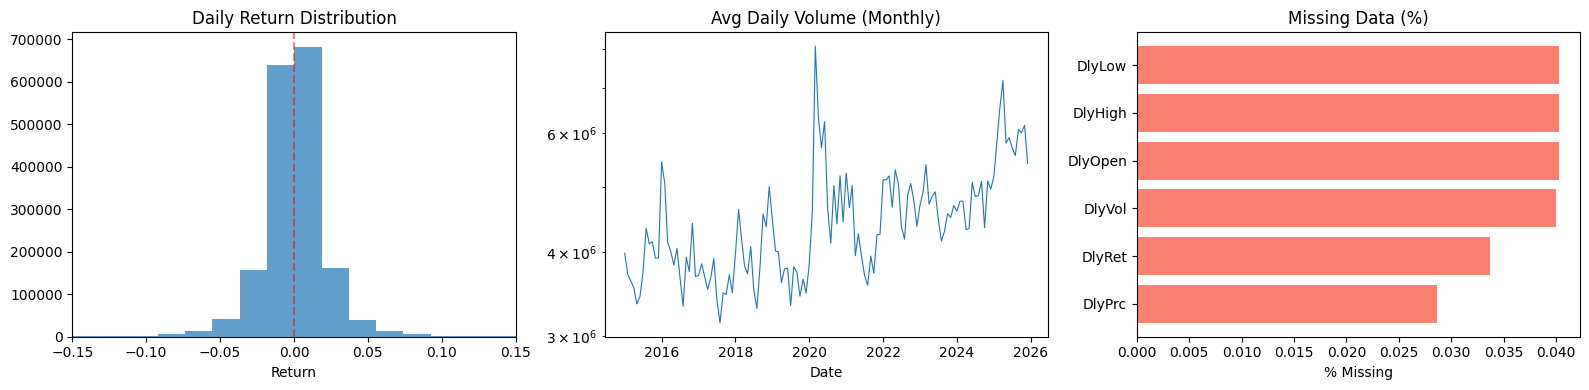

In [6]:
# EDA: Return distribution and missing data summary
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Daily return distribution
axes[0].hist(crsp["DlyRet"].dropna(), bins=200, edgecolor="none", alpha=0.7)
axes[0].set_xlim(-0.15, 0.15)
axes[0].set_title("Daily Return Distribution")
axes[0].set_xlabel("Return")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

# Trading volume over time (log scale, monthly avg)
monthly_vol = crsp.groupby(crsp["DlyCalDt"].dt.to_period("M"))["DlyVol"].mean()
axes[1].plot(monthly_vol.index.to_timestamp(), monthly_vol.values, linewidth=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Avg Daily Volume (Monthly)")
axes[1].set_xlabel("Date")

# Missing data heatmap for key columns
cols = ["DlyPrc", "DlyRet", "DlyVol", "DlyOpen", "DlyHigh", "DlyLow"]
missing_pct = crsp[cols].isnull().mean() * 100
axes[2].barh(cols, missing_pct, color="salmon")
axes[2].set_title("Missing Data (%)")
axes[2].set_xlabel("% Missing")

plt.tight_layout()
plt.show()

<a id="3-features"></a>
## 3. Feature Engineering & Graph Construction

### 3.1 OHLCV Feature Preparation
We select a subset of actively traded stocks with sufficient history, then construct normalized OHLCV feature vectors per trading day.

### 3.2 Sector Graph via GICS Codes
We build the sector adjacency matrix: two stocks share an edge (weight=1) if they belong to the same GICS sub-industry. The Graph Laplacian is then eigendecomposed to produce spectral coordinates for WIRE.

In [7]:
# --- 3.1 Filter stocks with sufficient coverage ---
# Keep stocks that have at least 80% of trading days present
date_range = crsp["DlyCalDt"].nunique()
stock_counts = crsp.groupby("PERMNO")["DlyCalDt"].count()
valid_permnos = stock_counts[stock_counts >= date_range * 0.8].index

# Intersect with Compustat to ensure we have sector labels
sector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsubind"]
gsector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsector"]
valid_permnos = valid_permnos[valid_permnos.isin(sector_map.index)]

# Top 100 by avg volume — clean, liquid, well-covered stocks
avg_vol = crsp[crsp["PERMNO"].isin(valid_permnos)].groupby("PERMNO")["DlyVol"].mean()
top_permnos = sorted(avg_vol.nlargest(100).index.tolist())

crsp_sub = crsp[crsp["PERMNO"].isin(top_permnos)].copy()
print(f"Selected {len(top_permnos)} stocks, {len(crsp_sub)} daily records")

# Create stock index mapping
permno_to_idx = {p: i for i, p in enumerate(top_permnos)}
idx_to_permno = {i: p for p, i in permno_to_idx.items()}
N_STOCKS = len(top_permnos)
print(f"Stock universe: N={N_STOCKS}")

# Show sector breakdown
sector_counts = pd.Series([gsector_map.get(p, -1) for p in top_permnos]).value_counts().sort_index()
print(f"\nGICS Sector distribution:\n{sector_counts}")

Selected 100 stocks, 275177 daily records
Stock universe: N=100

GICS Sector distribution:
10    15
15     2
20     8
25    14
30     9
35     9
40    14
45    15
50    10
55     3
60     1
Name: count, dtype: int64


In [8]:
# --- 3.1 continued: Build OHLCV feature tensor ---
# Features per stock per day: [Open/Close, High/Close, Low/Close, Close, log(Vol), Return]

FEATURE_COLS = ["DlyOpen", "DlyHigh", "DlyLow", "DlyPrc", "DlyVol", "DlyRet"]

def build_feature_matrix(df, permnos, permno_to_idx):
    """Build (T, N, F) tensor from CRSP daily data (vectorized)."""
    dates = sorted(df["DlyCalDt"].unique())
    T = len(dates)
    N = len(permnos)
    F = 6

    date_to_tidx = {d: t for t, d in enumerate(dates)}
    feat = np.full((T, N, F), np.nan, dtype=np.float32)

    # Vectorized: map columns to indices
    df = df.copy()
    df["_tidx"] = df["DlyCalDt"].map(date_to_tidx)
    df["_nidx"] = df["PERMNO"].map(permno_to_idx)
    df = df.dropna(subset=["_tidx", "_nidx"])

    tidx = df["_tidx"].astype(int).values
    nidx = df["_nidx"].astype(int).values

    close = df["DlyPrc"].values.astype(np.float32)
    close_safe = np.where(close == 0, 1.0, close)

    feat[tidx, nidx, 0] = df["DlyOpen"].values / close_safe   # O/C
    feat[tidx, nidx, 1] = df["DlyHigh"].values / close_safe   # H/C
    feat[tidx, nidx, 2] = df["DlyLow"].values / close_safe    # L/C
    feat[tidx, nidx, 3] = close                                 # raw close
    feat[tidx, nidx, 4] = np.log1p(df["DlyVol"].values)        # log volume
    feat[tidx, nidx, 5] = df["DlyRet"].values                  # return

    return feat, dates

features, dates = build_feature_matrix(crsp_sub, top_permnos, permno_to_idx)
print(f"Feature tensor shape: {features.shape}  (T={features.shape[0]}, N={features.shape[1]}, F={features.shape[2]})")
print(f"NaN fraction: {np.isnan(features).mean():.4f}")

Feature tensor shape: (2766, 100, 6)  (T=2766, N=100, F=6)
NaN fraction: 0.0066


In [9]:
# --- 3.1b Add Compustat Fundamental Features ---
# Quarterly fundamentals (atq, ceqq, niq) → derive ROE, leverage, profit margin
# Forward-fill to daily frequency using report date (rdq) to avoid lookahead bias

fund = compustat[["PERMNO", "datadate", "rdq", "atq", "ceqq", "niq"]].copy()
fund["datadate"] = pd.to_datetime(fund["datadate"])
fund["rdq"] = pd.to_datetime(fund["rdq"])

# Use report date (rdq) as the date features become available (no lookahead)
# If rdq is missing, use datadate + 45 days as conservative estimate
fund["avail_date"] = fund["rdq"].fillna(fund["datadate"] + pd.Timedelta(days=45))

# Derive ratios (winsorize to handle extreme values)
def safe_ratio(num, denom, clip=10):
    ratio = num / denom.replace(0, np.nan)
    return ratio.clip(-clip, clip)

fund["roe"] = safe_ratio(fund["niq"], fund["ceqq"])         # return on equity
fund["leverage"] = safe_ratio(fund["atq"], fund["ceqq"])    # financial leverage
fund["profit_margin"] = safe_ratio(fund["niq"], fund["atq"]) # profit margin (ROA proxy)

# Log total assets as size proxy
fund["log_assets"] = np.log1p(fund["atq"].clip(lower=0))

FUND_FEATURES = ["roe", "leverage", "profit_margin", "log_assets"]

# Merge with daily dates: for each stock-day, use most recent available fundamental
def merge_fundamentals(features_array, dates, permnos, permno_to_idx, fund_df):
    """Add fundamental features to the (T, N, F) tensor. Returns (T, N, F+4)."""
    T, N, F_old = features_array.shape
    F_new = len(FUND_FEATURES)
    fund_feat = np.full((T, N, F_new), np.nan, dtype=np.float32)

    for permno in permnos:
        n_idx = permno_to_idx[permno]
        stock_fund = fund_df[fund_df["PERMNO"] == permno].sort_values("avail_date")

        if len(stock_fund) == 0:
            continue

        # For each quarter, fill forward from avail_date to next avail_date
        for _, row in stock_fund.iterrows():
            avail = row["avail_date"]
            vals = [row[c] for c in FUND_FEATURES]

            for t, d in enumerate(dates):
                if d >= avail:
                    fund_feat[t, n_idx, :] = vals

    # Forward fill: for each stock, last valid value persists
    for n in range(N):
        for f in range(F_new):
            last_valid = np.nan
            for t in range(T):
                if not np.isnan(fund_feat[t, n, f]):
                    last_valid = fund_feat[t, n, f]
                else:
                    fund_feat[t, n, f] = last_valid

    # Concatenate: (T, N, F_old) + (T, N, F_new) → (T, N, F_old + F_new)
    combined = np.concatenate([features_array, fund_feat], axis=2)
    return combined

features = merge_fundamentals(features, dates, top_permnos, permno_to_idx, fund)
print(f"Expanded feature tensor: {features.shape}  (T, N, F={features.shape[2]})")
print(f"Features: [O/C, H/C, L/C, Close, logVol, Ret, ROE, Leverage, ProfitMargin, LogAssets]")
print(f"NaN fraction: {np.isnan(features).mean():.4f}")

# Quick stats on fundamental features
for i, name in enumerate(FUND_FEATURES):
    vals = features[:, :, 6 + i].flatten()
    vals = vals[~np.isnan(vals)]
    print(f"  {name:15s}: mean={vals.mean():.4f}, std={vals.std():.4f}, "
          f"min={vals.min():.4f}, max={vals.max():.4f}")

Expanded feature tensor: (2766, 100, 10)  (T, N, F=10)
Features: [O/C, H/C, L/C, Close, logVol, Ret, ROE, Leverage, ProfitMargin, LogAssets]
NaN fraction: 0.0254
  roe            : mean=0.0379, std=0.5289, min=-10.0000, max=10.0000
  leverage       : mean=3.6636, std=3.8518, min=-10.0000, max=10.0000
  profit_margin  : mean=0.0125, std=0.0312, min=-0.3346, max=0.3373
  log_assets     : mean=11.1620, std=1.4121, min=6.7977, max=15.3329


Sector graph (coarse):     100 nodes, 541 edges, density=0.1093
Sub-industry graph (fine): 100 nodes, 99 edges, density=0.0200


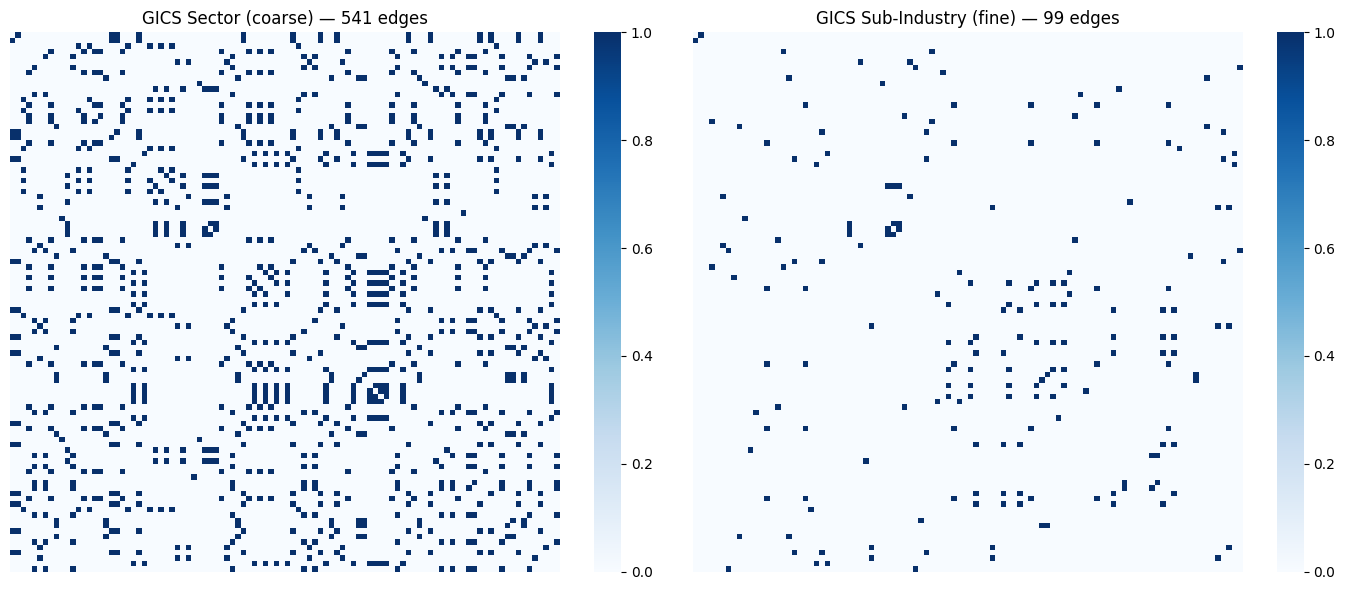

In [10]:
# --- 3.2 Sector Graph Construction ---
# Build two adjacency matrices:
#   A_sector:  same GICS sector (coarse, ~11 sectors → dense graph)
#   A_subind:  same GICS sub-industry (fine-grained → sparser)

sorted_permnos = top_permnos  # already sorted
sub_industries = np.array([sector_map.get(p, -1) for p in sorted_permnos])
sectors = np.array([gsector_map.get(p, -1) for p in sorted_permnos])

# Vectorized adjacency construction
def build_adjacency(labels):
    """Build adjacency matrix: A[i,j]=1 if labels[i]==labels[j] and label != -1."""
    N = len(labels)
    L = labels.reshape(-1, 1)
    A = ((L == L.T) & (L != -1)).astype(np.float32)
    np.fill_diagonal(A, 0)
    return A

A_sector = build_adjacency(sectors)
A_subind = build_adjacency(sub_industries)

n_edges_sector = int(A_sector.sum() / 2)
n_edges_subind = int(A_subind.sum() / 2)
print(f"Sector graph (coarse):     {N_STOCKS} nodes, {n_edges_sector} edges, "
      f"density={n_edges_sector / (N_STOCKS*(N_STOCKS-1)/2):.4f}")
print(f"Sub-industry graph (fine): {N_STOCKS} nodes, {n_edges_subind} edges, "
      f"density={n_edges_subind / (N_STOCKS*(N_STOCKS-1)/2):.4f}")

# Use SECTOR (coarse) graph for WIRE — denser graph gives better spectral coords
A_graph = A_sector

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(A_sector, cmap="Blues", xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title(f"GICS Sector (coarse) — {n_edges_sector} edges")
sns.heatmap(A_subind, cmap="Blues", xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title(f"GICS Sub-Industry (fine) — {n_edges_subind} edges")
plt.tight_layout()
plt.show()

GVKEY mappings: 731 | CUSIP mappings: 98

--- (A) TNIC Competitor Graph ---
TNIC year=2023, pairs in universe: 361
TNIC graph: 100 nodes, 68 edges, density=0.0137

--- (B) Supply Chain Graph ---
Supply chain rows with supplier in universe: 3148
Supply chain graph: 100 nodes, 310 edges, density=0.0626

--- (C) Ownership Co-Holding Graph ---
13F rows in universe: 1562110
Managers holding universe stocks: 7883
Ownership graph: 100 nodes, 1166 edges, density=0.2356


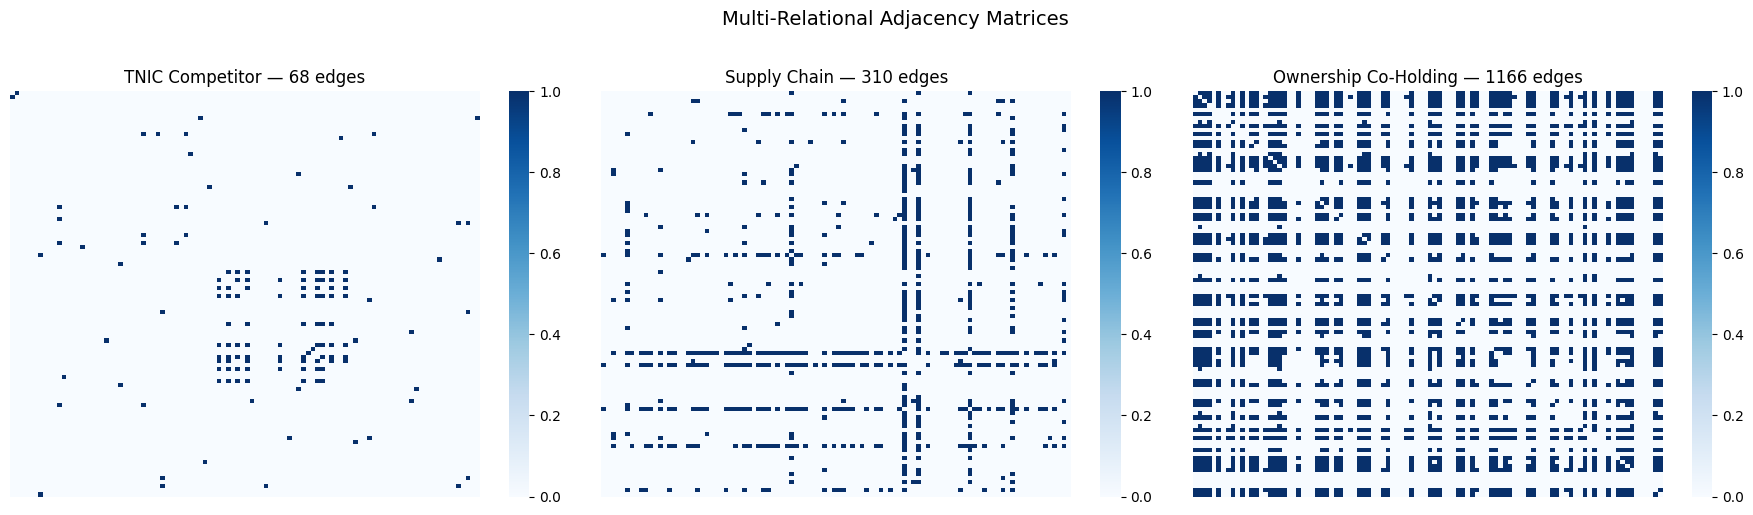


Graph                        Edges    Density
---------------------------------------------
Sector (GICS)                  541     0.1093
TNIC Competitor                 68     0.0137
Supply Chain                   310     0.0626
Ownership                     1166     0.2356


In [11]:
# --- 3.3 Multi-Relational Graph Construction ---
# Build 3 additional adjacency matrices: TNIC Competitor, Supply Chain, Ownership
# Uses pre-filtered files for speed (see Data/ folder)

# --- GVKEY / CUSIP mappings ---
comp = compustat.drop_duplicates("PERMNO", keep="last")
gvkey_to_permno = dict(zip(comp["GVKEY"].astype(int), comp["PERMNO"].astype(int)))
permno_to_gvkey = {v: k for k, v in gvkey_to_permno.items()}

cusip_df = crsp_sub.drop_duplicates("PERMNO", keep="last")[["PERMNO", "HdrCUSIP"]].dropna()
cusip_to_permno = dict(zip(cusip_df["HdrCUSIP"].str[:8], cusip_df["PERMNO"].astype(int)))
permno_to_cusip = {v: k for k, v in cusip_to_permno.items()}

universe_gvkeys = set(permno_to_gvkey.get(p) for p in top_permnos if p in permno_to_gvkey)
print(f"GVKEY mappings: {len(gvkey_to_permno)} | CUSIP mappings: {len(cusip_to_permno)}")

# ============================================================
# (A) TNIC Competitor Graph — Hoberg-Phillips text-based similarity
# ============================================================
print("\n--- (A) TNIC Competitor Graph ---")
tnic = pd.read_csv("<Enter your data path here>/tnic3_filtered.csv")
latest_year = tnic["year"].max()
tnic = tnic[(tnic["year"] == latest_year) &
            tnic["gvkey1"].isin(universe_gvkeys) &
            tnic["gvkey2"].isin(universe_gvkeys)]
print(f"TNIC year={latest_year}, pairs in universe: {len(tnic)}")

# Connect if score > median (top 50% similarity)
score_threshold = tnic["score"].median()
tnic_edges = tnic[tnic["score"] >= score_threshold]

A_tnic = np.zeros((N_STOCKS, N_STOCKS), dtype=np.float32)
for _, row in tnic_edges.iterrows():
    p1 = gvkey_to_permno.get(int(row["gvkey1"]))
    p2 = gvkey_to_permno.get(int(row["gvkey2"]))
    if p1 in permno_to_idx and p2 in permno_to_idx:
        i, j = permno_to_idx[p1], permno_to_idx[p2]
        A_tnic[i, j] = 1.0
        A_tnic[j, i] = 1.0
np.fill_diagonal(A_tnic, 0)

n_tnic = int(A_tnic.sum() / 2)
print(f"TNIC graph: {N_STOCKS} nodes, {n_tnic} edges, "
      f"density={n_tnic / (N_STOCKS*(N_STOCKS-1)/2):.4f}")

# ============================================================
# (B) Supply Chain Graph — Compustat Segment customer relationships
# ============================================================
print("\n--- (B) Supply Chain Graph ---")
sc = pd.read_csv("<Enter your data path here>/supplychain_segments.csv")
sc["gvkey"] = sc["gvkey"].astype(int)
sc_in_universe = sc[sc["gvkey"].isin(universe_gvkeys)].copy()
print(f"Supply chain rows with supplier in universe: {len(sc_in_universe)}")

# Match customer names to tickers
ticker_df = crsp_sub.drop_duplicates("PERMNO", keep="last")[["PERMNO", "Ticker"]].dropna()
ticker_to_permno = dict(zip(ticker_df["Ticker"].str.upper(), ticker_df["PERMNO"].astype(int)))

A_supply = np.zeros((N_STOCKS, N_STOCKS), dtype=np.float32)
for _, row in sc_in_universe.iterrows():
    supplier_permno = gvkey_to_permno.get(int(row["gvkey"]))
    if supplier_permno not in permno_to_idx:
        continue
    cust_name = str(row["cnms"]).upper().strip()
    for ticker, pno in ticker_to_permno.items():
        if ticker in cust_name or cust_name in ticker:
            if pno in permno_to_idx and pno != supplier_permno:
                i, j = permno_to_idx[supplier_permno], permno_to_idx[pno]
                A_supply[i, j] = 1.0
                A_supply[j, i] = 1.0

n_supply = int(A_supply.sum() / 2)
print(f"Supply chain graph: {N_STOCKS} nodes, {n_supply} edges, "
      f"density={n_supply / (N_STOCKS*(N_STOCKS-1)/2):.4f}")

# ============================================================
# (C) Ownership Co-Holding Graph — 13F institutional holdings
# ============================================================
print("\n--- (C) Ownership Co-Holding Graph ---")

universe_cusips = set()
for p in top_permnos:
    c = permno_to_cusip.get(p)
    if c and isinstance(c, str):
        universe_cusips.add(c[:8])

cusip_to_idx_map = {}
for p in top_permnos:
    c = permno_to_cusip.get(p)
    if c and isinstance(c, str) and c[:8] in universe_cusips:
        cusip_to_idx_map[c[:8]] = permno_to_idx[p]

# Read pre-filtered 13F data (last 2 years, universe CUSIPs only)
mgr_holdings = {}
own = pd.read_csv("<Enter your data path here>/ownership_13f.csv", dtype={"cusip": str})
own = own.dropna(subset=["cusip", "shares"])
own = own[own["shares"] > 0]
own["cusip8"] = own["cusip"].str[:8]
own = own[own["cusip8"].isin(universe_cusips)]
print(f"13F rows in universe: {len(own)}")

for mgrno, grp in own.groupby("mgrno"):
    mgr_holdings[mgrno] = set(grp["cusip8"].unique())

print(f"Managers holding universe stocks: {len(mgr_holdings)}")

# Co-holding matrix: count shared managers (skip very broad/tiny holders)
co_hold = np.zeros((N_STOCKS, N_STOCKS), dtype=np.float32)
for mgrno, held in mgr_holdings.items():
    held_in_univ = [cusip_to_idx_map[c] for c in held if c in cusip_to_idx_map]
    if 3 <= len(held_in_univ) <= 50:
        for a in held_in_univ:
            for b in held_in_univ:
                if a != b:
                    co_hold[a, b] += 1

upper_tri = co_hold[np.triu_indices(N_STOCKS, k=1)]
threshold = np.percentile(upper_tri[upper_tri > 0], 75) if (upper_tri > 0).any() else 1
A_ownership = (co_hold >= threshold).astype(np.float32)
np.fill_diagonal(A_ownership, 0)

n_own = int(A_ownership.sum() / 2)
print(f"Ownership graph: {N_STOCKS} nodes, {n_own} edges, "
      f"density={n_own / (N_STOCKS*(N_STOCKS-1)/2):.4f}")

# ============================================================
# Summary
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, A, n) in zip(axes, [
    ("TNIC Competitor", A_tnic, n_tnic),
    ("Supply Chain", A_supply, n_supply),
    ("Ownership Co-Holding", A_ownership, n_own)
]):
    sns.heatmap(A, cmap="Blues", xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title(f"{name} — {n} edges")
plt.suptitle("Multi-Relational Adjacency Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Graph':<25} {'Edges':>8} {'Density':>10}")
print("-" * 45)
for name, n in [("Sector (GICS)", n_edges_sector), ("TNIC Competitor", n_tnic),
                ("Supply Chain", n_supply), ("Ownership", n_own)]:
    density = n / (N_STOCKS * (N_STOCKS - 1) / 2)
    print(f"{name:<25} {n:>8} {density:>10.4f}")

Graph                  Edges   Density      Gap    Energy     Status
-----------------------------------------------------------------
Sector                   541    0.1093  -0.0000     99.00     ACTIVE
TNIC                      68    0.0137  -0.0000     44.00    SKIPPED
Supply Chain             310    0.0626  -0.0000     77.00     ACTIVE
Ownership               1166    0.2356  -0.0000     58.00     ACTIVE

Active graphs: ['Sector', 'Supply Chain', 'Ownership']
Dimension allocation (total=16):
  Sector               → 7 dims
  Supply Chain         → 5 dims
  Ownership            → 4 dims

Computing spectral coordinates:
  [Sector] 7 dims, gap=-0.0000
  [Supply Chain] 5 dims, gap=-0.0000
  [Ownership] 4 dims, gap=-0.0000

Super-coordinates shape: (100, 16)  (N=100, M=16)


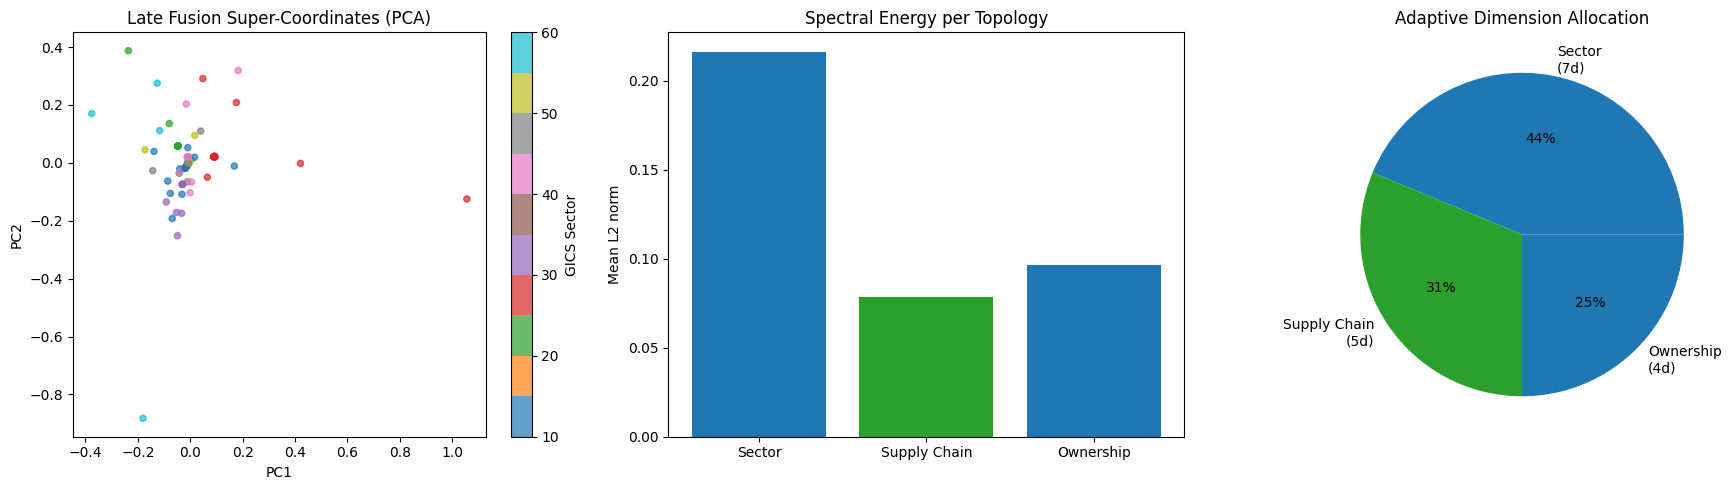

In [12]:
# --- 3.4 Late Fusion: Sector + Supply Chain Spectral Coordinates ---
# Only fuse graphs with sufficient density. TNIC (68 edges) and Ownership
# are too sparse for 100-stock universe — spectral coords become noise.
# Ablation in Section 8 compares all configurations.

M_TOTAL = 16  # total spectral budget (same as v6 sector-only baseline)

def spectral_quality(A, name=""):
    """Compute spectral gap and energy as graph quality metrics."""
    n_edges = int(A.sum() / 2)
    density = n_edges / (A.shape[0] * (A.shape[0] - 1) / 2) if A.shape[0] > 1 else 0
    if n_edges == 0:
        return {"name": name, "edges": 0, "density": 0, "gap": 0, "energy": 0}
    L = laplacian(A, normed=True)
    eigenvalues = eigh(L, eigvals_only=True)
    gap = eigenvalues[1]
    energy = eigenvalues[1:].sum()
    return {"name": name, "edges": n_edges, "density": density, "gap": gap, "energy": energy}

# Evaluate ALL graphs for the report
all_graphs = [
    (A_sector, "Sector"), (A_tnic, "TNIC"),
    (A_supply, "Supply Chain"), (A_ownership, "Ownership"),
]
all_quality = [spectral_quality(A, name) for A, name in all_graphs]

print(f"{'Graph':<20} {'Edges':>7} {'Density':>9} {'Gap':>8} {'Energy':>9} {'Status':>10}")
print("-" * 65)
MIN_DENSITY = 0.02  # threshold: graphs below this are too sparse
for q in all_quality:
    status = "ACTIVE" if q["density"] >= MIN_DENSITY else "SKIPPED"
    print(f"{q['name']:<20} {q['edges']:>7} {q['density']:>9.4f} {q['gap']:>8.4f} {q['energy']:>9.2f} {status:>10}")

# Use only Sector + Supply Chain (density > 0.02)
active_graphs = [(A, name) for (A, name), q in zip(all_graphs, all_quality) if q["density"] >= MIN_DENSITY]
active_quality = [q for q in all_quality if q["density"] >= MIN_DENSITY]
print(f"\nActive graphs: {[name for _, name in active_graphs]}")

# Allocate dims proportional to energy
energies = np.array([q["energy"] for q in active_quality])
shares = energies / energies.sum()
dim_alloc = np.round(shares * M_TOTAL).astype(int)
dim_alloc[-1] = M_TOTAL - dim_alloc[:-1].sum()  # fix rounding

print(f"Dimension allocation (total={M_TOTAL}):")
for (_, name), d in zip(active_graphs, dim_alloc):
    print(f"  {name:<20} → {d} dims")

# Compute spectral coordinates
def compute_spectral(A, m, name=""):
    L = laplacian(A, normed=True)
    eigenvalues, eigenvectors = eigh(L)
    coords = eigenvectors[:, 1:m + 1].astype(np.float32)
    if coords.shape[1] < m:
        pad = np.zeros((coords.shape[0], m - coords.shape[1]), dtype=np.float32)
        coords = np.hstack([coords, pad])
    print(f"  [{name}] {m} dims, gap={eigenvalues[1]:.4f}")
    return coords

print("\nComputing spectral coordinates:")
spec_list = [compute_spectral(A, m, name) for (A, name), m in zip(active_graphs, dim_alloc)]

spectral_coords = np.hstack(spec_list)
M_SPECTRAL = spectral_coords.shape[1]
print(f"\nSuper-coordinates shape: {spectral_coords.shape}  (N={N_STOCKS}, M={M_SPECTRAL})")

# Visualize
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(spectral_coords)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter = axes[0].scatter(coords_2d[:, 0], coords_2d[:, 1],
                          c=sectors, cmap="tab10", alpha=0.7, s=20)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("Late Fusion Super-Coordinates (PCA)")
plt.colorbar(scatter, ax=axes[0], label="GICS Sector")

norms = [np.linalg.norm(s, axis=1).mean() for s in spec_list]
axes[1].bar([name for _, name in active_graphs], norms,
            color=["#1f77b4", "#2ca02c"][:len(active_graphs)])
axes[1].set_ylabel("Mean L2 norm")
axes[1].set_title("Spectral Energy per Topology")

axes[2].pie(dim_alloc, labels=[f"{name}\n({d}d)" for (_, name), d in zip(active_graphs, dim_alloc)],
            autopct="%1.0f%%", colors=["#1f77b4", "#2ca02c"][:len(active_graphs)])
axes[2].set_title("Adaptive Dimension Allocation")

plt.tight_layout()
plt.show()

In [13]:
# --- 3.3 Dataset class for sliding-window OHLCV + Fundamentals ---

LOOKBACK = 20    # N-day lookback window
HORIZON = 5      # T+5 prediction horizon
# Input: [O/C, H/C, L/C, logVol, Ret, ROE, Leverage, ProfitMargin, LogAssets] (skip raw close at idx 3)
INPUT_DIM = 9

class StockDataset(Dataset):
    """Sliding-window dataset: predicts T+5 return from OHLCV + fundamental features."""

    def __init__(self, features, lookback=LOOKBACK, horizon=HORIZON):
        self.lookback = lookback
        self.horizon = horizon
        self.samples = []

        T, N, F = features.shape
        # Skip raw close (idx 3), keep everything else
        input_idx = [0, 1, 2, 4, 5, 6, 7, 8, 9]

        for t in range(lookback, T - horizon):
            x = features[t - lookback:t, :, :][:, :, input_idx]

            close_now = features[t, :, 3]
            close_future = features[t + horizon, :, 3]
            y = (close_future / close_now) - 1.0

            valid = ~(np.isnan(x).any(axis=(0, 2)) | np.isnan(y))
            if valid.sum() < N * 0.5:
                continue

            x = np.nan_to_num(x, nan=0.0)
            y = np.nan_to_num(y, nan=0.0)

            self.samples.append((x.transpose(1, 0, 2), y))  # (N, lookback, F_in), (N,)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Build dataset and split: train 70%, val 15%, test 15%
dataset = StockDataset(features)
n_total = len(dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_ds = torch.utils.data.Subset(dataset, range(n_train))
val_ds = torch.utils.data.Subset(dataset, range(n_train, n_train + n_val))
test_ds = torch.utils.data.Subset(dataset, range(n_train + n_val, n_total))

print(f"Total samples: {n_total}, Train: {n_train}, Val: {n_val}, Test: {n_test}")
print(f"Sample shape — X: {dataset[0][0].shape}, Y: {dataset[0][1].shape}")
print(f"Input features (9): O/C, H/C, L/C, logVol, Ret, ROE, Leverage, ProfitMargin, LogAssets")

Total samples: 2600, Train: 1819, Val: 390, Test: 391
Sample shape — X: torch.Size([100, 20, 9]), Y: torch.Size([100])
Input features (9): O/C, H/C, L/C, logVol, Ret, ROE, Leverage, ProfitMargin, LogAssets


<a id="4-lstm"></a>
## 4. Baseline Model: LSTM

The first baseline is a standalone LSTM that processes each stock's lookback window independently (no cross-sectional information). This follows the temporal extraction component of the DGT pipeline.

Architecture: `OHLCV+Fundamentals (N, 20, 9) → LSTM → 64-dim embedding → Linear → T+5 return prediction`

Input features: O/C ratio, H/C ratio, L/C ratio, log-volume, daily return, ROE, leverage, profit margin, log(total assets)

In [14]:
# --- 4.1 Baseline LSTM Model ---

class BaselineLSTM(nn.Module):
    """Per-stock LSTM encoder with linear prediction head."""

    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """
        Args:
            x: (B, N, T, F) — batch of stock windows
        Returns:
            pred: (B, N), embed: (B, N, hidden)
        """
        B, N, T, F = x.shape
        x = x.reshape(B * N, T, F)
        _, (h_n, _) = self.lstm(x)
        embed = h_n[-1]
        pred = self.head(embed).squeeze(-1)
        return pred.reshape(B, N), embed.reshape(B, N, -1)

model_lstm = BaselineLSTM().to(device)
n_params = sum(p.numel() for p in model_lstm.parameters())
print(f"Baseline LSTM — {n_params:,} parameters")

Baseline LSTM — 54,593 parameters


<a id="5-wire"></a>
## 5. WIRE: Wavelet-Induced Rotary Encodings

Following Reid et al. (2024), WIRE applies RoPE using graph spectral coordinates:

1. Compute Laplacian eigenvectors $\{u_k\}$ → spectral coordinates $r_i \in \mathbb{R}^m$ for each node $i$
2. For each 2D block of query/key vectors, compute rotation angle $\theta_n = \omega_n^\top r_i$
3. Apply 2D rotation: $\rho(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$

This makes the attention dot-product $q_i^\top k_j$ sensitive to the graph distance between nodes $i$ and $j$, injecting structural topology directly into attention without explicit edge weights.

In [15]:
# --- 5.1 WIRE Implementation (Eq. 2 & 11 from Reid et al.) ---

class WIRE(nn.Module):
    """Wavelet-Induced Rotary Encodings for graphs.

    Given spectral coordinates r_i in R^m for each node, WIRE rotates
    query/key vectors by angles theta_n = omega_n^T r_i for each 2D block.
    """

    def __init__(self, d_model, m_spectral):
        super().__init__()
        self.d_model = d_model
        self.m_spectral = m_spectral
        n_blocks = d_model // 2
        # Larger init so rotations actually differentiate nodes from the start
        self.omega = nn.Parameter(torch.randn(n_blocks, m_spectral) * 1.0)

    def forward(self, z, spectral_coords):
        """Apply WIRE rotation to query or key vectors.

        Args:
            z:               (B, N, H, d) — query or key vectors
            spectral_coords: (N, m) — Laplacian spectral coordinates
        Returns:
            z_rotated:       (B, N, H, d)
        """
        B, N, H, d = z.shape
        n_blocks = d // 2

        # theta[i, n] = omega_n^T r_i
        theta = spectral_coords @ self.omega.T  # (N, n_blocks)

        z = z.reshape(B, N, H, n_blocks, 2)

        cos_t = torch.cos(theta)[None, :, None, :, None]  # (1, N, 1, n_blocks, 1)
        sin_t = torch.sin(theta)[None, :, None, :, None]

        z0, z1 = z[..., 0:1], z[..., 1:2]
        z_rot = torch.cat([
            z0 * cos_t - z1 * sin_t,
            z0 * sin_t + z1 * cos_t
        ], dim=-1)

        return z_rot.reshape(B, N, H, d)

# Sanity check
wire = WIRE(d_model=64, m_spectral=M_SPECTRAL)
dummy_z = torch.randn(2, N_STOCKS, 4, 64)
sc = torch.tensor(spectral_coords, dtype=torch.float32)
out = wire(dummy_z, sc)
print(f"WIRE input: {dummy_z.shape} -> output: {out.shape}")
print(f"Norm preserved: input={dummy_z.norm():.4f}, output={out.norm():.4f}")

# Verify rotations actually differ across nodes
theta_check = sc @ wire.omega.T.detach()
print(f"Rotation angle range: [{theta_check.min():.3f}, {theta_check.max():.3f}]")
print(f"Angle std across nodes: {theta_check.std(dim=0).mean():.4f}")

WIRE input: torch.Size([2, 100, 4, 64]) -> output: torch.Size([2, 100, 4, 64])
Norm preserved: input=226.3505, output=226.3506
Rotation angle range: [-3.150, 2.828]
Angle std across nodes: 0.4114


<a id="6-transformer"></a>
## 6. Graph Transformer with WIRE

The full pipeline:
1. **LSTM Encoder**: Each stock's OHLCV window → 64-dim temporal embedding
2. **WIRE Rotation**: Spectral coordinates rotate Q/K vectors to encode graph topology
3. **Multi-Head Self-Attention**: Cross-sectional attention over all N stocks
4. **Prediction Head**: Linear layer outputs T+5 return forecast

In [16]:
# --- 6.1 WIRE-enhanced Graph Transformer Attention ---

class WIREAttentionLayer(nn.Module):
    """Multi-head self-attention with WIRE positional encoding and residual gate."""

    def __init__(self, d_model=64, n_heads=4, m_spectral=M_SPECTRAL, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.wire = WIRE(d_model=self.d_k, m_spectral=m_spectral)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

        # Learnable gate: controls how much attention output mixes with residual
        # Initialized near 0 so model starts close to pure LSTM baseline
        self.gate = nn.Parameter(torch.tensor(0.0))

    def forward(self, x, spectral_coords):
        B, N, _ = x.shape
        H, d_k = self.n_heads, self.d_k

        Q = self.W_q(x).reshape(B, N, H, d_k)
        K = self.W_k(x).reshape(B, N, H, d_k)
        V = self.W_v(x).reshape(B, N, H, d_k)

        Q = self.wire(Q, spectral_coords)
        K = self.wire(K, spectral_coords)

        Q = Q.permute(0, 2, 1, 3)
        K = K.permute(0, 2, 1, 3)
        V = V.permute(0, 2, 1, 3)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)
        out = out.permute(0, 2, 1, 3).reshape(B, N, self.d_model)
        out = self.W_o(out)

        # Gated residual: x + sigmoid(gate) * attention_output
        alpha = torch.sigmoid(self.gate)
        out = self.norm(x + alpha * out)
        return out, attn


class GraphTransformerWIRE(nn.Module):
    """LSTM temporal encoder + WIRE Graph Transformer with gated residual.

    Late Fusion: spectral_coords now contain concatenated eigenvectors from
    4 graph topologies (Sector, TNIC, Supply Chain, Ownership).
    WIRE omega learns which topological dimensions matter for each rotation block.
    """

    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, n_heads=4,
                 n_layers=2, m_spectral=M_SPECTRAL, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=dropout)

        self.attn_layers = nn.ModuleList([
            WIREAttentionLayer(hidden_dim, n_heads, m_spectral, dropout)
            for _ in range(n_layers)
        ])

        self.ffns = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.LayerNorm(hidden_dim)
            ) for _ in range(n_layers)
        ])

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x, spectral_coords):
        B, N, T, F = x.shape

        x_flat = x.reshape(B * N, T, F)
        _, (h_n, _) = self.lstm(x_flat)
        embed = h_n[-1].reshape(B, N, self.hidden_dim)

        attn_maps = []
        for attn_layer, ffn in zip(self.attn_layers, self.ffns):
            embed, attn = attn_layer(embed, spectral_coords)
            embed = ffn(embed) + embed
            attn_maps.append(attn)

        pred = self.head(embed).squeeze(-1)
        return pred, attn_maps

model_wire = GraphTransformerWIRE(m_spectral=M_SPECTRAL).to(device)
n_params = sum(p.numel() for p in model_wire.parameters())
print(f"Graph Transformer + WIRE (Late Fusion) — {n_params:,} parameters")
print(f"  M_SPECTRAL = {M_SPECTRAL} (8 dims × 4 graphs)")

# Show gate init values
for name, p in model_wire.named_parameters():
    if "gate" in name:
        print(f"  {name}: init={p.item():.4f}, sigmoid={torch.sigmoid(p).item():.4f}")

# WIRE omega shape check
for name, p in model_wire.named_parameters():
    if "omega" in name:
        print(f"  {name}: shape={list(p.shape)} (8 rotation blocks × {M_SPECTRAL} spectral dims)")

Graph Transformer + WIRE (Late Fusion) — 121,795 parameters
  M_SPECTRAL = 16 (8 dims × 4 graphs)
  attn_layers.0.gate: init=0.0000, sigmoid=0.5000
  attn_layers.1.gate: init=0.0000, sigmoid=0.5000
  attn_layers.0.wire.omega: shape=[8, 16] (8 rotation blocks × 16 spectral dims)
  attn_layers.1.wire.omega: shape=[8, 16] (8 rotation blocks × 16 spectral dims)


<a id="7-eval"></a>
## 7. Training & Evaluation

### Metrics
- **MSE Loss**: Standard regression loss on T+5 returns
- **Rank IC (Information Coefficient)**: Spearman correlation between predicted and actual cross-sectional return rankings — the standard alpha signal quality metric in quantitative finance

In [17]:
# --- 7.1 Training utilities ---

from scipy.stats import spearmanr

def rank_ic(pred, actual):
    """Compute Rank IC (Spearman correlation) across stocks.
    Works correctly with z-scored targets since Spearman only uses ranks."""
    pred_np = pred.detach().cpu().numpy().flatten()
    actual_np = actual.detach().cpu().numpy().flatten()
    mask = ~(np.isnan(pred_np) | np.isnan(actual_np))
    if mask.sum() < 10:
        return 0.0
    corr, _ = spearmanr(pred_np[mask], actual_np[mask])
    return corr if not np.isnan(corr) else 0.0


def train_epoch(model, loader, optimizer, spectral_coords_tensor=None, model_type="lstm"):
    """Train for one epoch. Returns avg loss and avg Rank IC."""
    model.train()
    total_loss, total_ic, n_batches = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        if model_type == "lstm":
            pred, _ = model(x)
        else:
            pred, _ = model(x, spectral_coords_tensor)

        loss = F.mse_loss(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_ic += rank_ic(pred, y)
        n_batches += 1

    return total_loss / n_batches, total_ic / n_batches


@torch.no_grad()
def evaluate(model, loader, spectral_coords_tensor=None, model_type="lstm"):
    """Evaluate model. Returns avg loss and avg Rank IC."""
    model.eval()
    total_loss, total_ic, n_batches = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if model_type == "lstm":
            pred, _ = model(x)
        else:
            pred, _ = model(x, spectral_coords_tensor)

        loss = F.mse_loss(pred, y)
        total_loss += loss.item()
        total_ic += rank_ic(pred, y)
        n_batches += 1

    return total_loss / n_batches, total_ic / n_batches

print("Training utilities defined.")

Training utilities defined.


In [18]:
# --- 7.2 Train both models ---

BATCH_SIZE = 16
N_EPOCHS = 150
LR = 1e-3
PATIENCE = 30

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

sc_tensor = torch.tensor(spectral_coords, dtype=torch.float32).to(device)


def train_model(model, optimizer, loader_tr, loader_va,
                spectral_coords_tensor=None, model_type="lstm",
                n_epochs=N_EPOCHS, patience=PATIENCE, warmup_epochs=5):
    """Train with LR warmup + ReduceLROnPlateau + early stopping on val IC."""
    best_val_ic = -np.inf
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": [], "train_ic": [], "val_ic": []}

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10, min_lr=1e-6)

    base_lrs = [pg["lr"] for pg in optimizer.param_groups]

    for epoch in range(n_epochs):
        if epoch < warmup_epochs:
            for pg, blr in zip(optimizer.param_groups, base_lrs):
                pg["lr"] = blr * (epoch + 1) / warmup_epochs

        tr_loss, tr_ic = train_epoch(model, loader_tr, optimizer,
                                     spectral_coords_tensor, model_type)
        va_loss, va_ic = evaluate(model, loader_va,
                                  spectral_coords_tensor, model_type)

        if epoch >= warmup_epochs:
            scheduler.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_ic"].append(tr_ic)
        history["val_ic"].append(va_ic)

        if va_ic > best_val_ic:
            best_val_ic = va_ic
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0:
            cur_lr = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch+1:3d} | TrLoss: {tr_loss:.6f} TrIC: {tr_ic:+.4f} | "
                  f"VaLoss: {va_loss:.6f} VaIC: {va_ic:+.4f} | "
                  f"best: {best_val_ic:+.4f} lr: {cur_lr:.1e}")

        if wait >= patience:
            print(f"  Early stop at epoch {epoch+1} (best val IC: {best_val_ic:+.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    total_epochs = len(history["train_loss"])
    print(f"  Finished {total_epochs} epochs, best val IC: {best_val_ic:+.4f}")
    return history


# --- Train Baseline LSTM ---
print("=" * 70)
print("Training Baseline LSTM")
print("=" * 70)

model_lstm = BaselineLSTM().to(device)
opt_lstm = torch.optim.AdamW(model_lstm.parameters(), lr=LR, weight_decay=1e-4)
history_lstm = train_model(model_lstm, opt_lstm, train_loader, val_loader,
                           model_type="lstm")

# --- Train Graph Transformer + WIRE ---
print("\n" + "=" * 70)
print("Training Graph Transformer + WIRE (with gated residual)")
print("=" * 70)

model_wire = GraphTransformerWIRE(m_spectral=M_SPECTRAL).to(device)

wire_params = []
gate_params = []
other_params = []
for name, param in model_wire.named_parameters():
    if "omega" in name:
        wire_params.append(param)
    elif "gate" in name:
        gate_params.append(param)
    else:
        other_params.append(param)

print(f"  Param groups: {len(other_params)} base, {len(wire_params)} omega, {len(gate_params)} gate")

opt_wire = torch.optim.AdamW([
    {"params": other_params, "lr": LR, "weight_decay": 1e-4},
    {"params": wire_params, "lr": LR * 10, "weight_decay": 0.0},
    {"params": gate_params, "lr": LR * 5, "weight_decay": 0.0},
], lr=LR)

history_wire = train_model(model_wire, opt_wire, train_loader, val_loader,
                           sc_tensor, model_type="wire")

# Print learned gate values
print("\n  Learned gate values:")
for name, p in model_wire.named_parameters():
    if "gate" in name:
        print(f"    {name}: {p.item():+.4f} → sigmoid={torch.sigmoid(p).item():.4f}")

Training Baseline LSTM
  Epoch  10 | TrLoss: 0.005681 TrIC: +0.0068 | VaLoss: 0.002919 VaIC: -0.0163 | best: -0.0131 lr: 1.0e-03
  Epoch  20 | TrLoss: 0.005653 TrIC: +0.0102 | VaLoss: 0.002824 VaIC: -0.0182 | best: -0.0131 lr: 1.0e-03
  Epoch  30 | TrLoss: 0.005652 TrIC: +0.0094 | VaLoss: 0.002823 VaIC: -0.0177 | best: -0.0131 lr: 1.0e-03
  Early stop at epoch 31 (best val IC: -0.0131)
  Finished 31 epochs, best val IC: -0.0131

Training Graph Transformer + WIRE (with gated residual)
  Param groups: 44 base, 2 omega, 2 gate
  Epoch  10 | TrLoss: 0.005653 TrIC: -0.0004 | VaLoss: 0.002822 VaIC: +0.0019 | best: +0.0126 lr: 1.0e-03
  Epoch  20 | TrLoss: 0.005646 TrIC: +0.0013 | VaLoss: 0.002822 VaIC: +0.0000 | best: +0.0126 lr: 5.0e-04
  Epoch  30 | TrLoss: 0.005643 TrIC: -0.0029 | VaLoss: 0.002821 VaIC: +0.0000 | best: +0.0126 lr: 2.5e-04
  Early stop at epoch 35 (best val IC: +0.0126)
  Finished 35 epochs, best val IC: +0.0126

  Learned gate values:
    attn_layers.0.gate: +0.0381 → sig

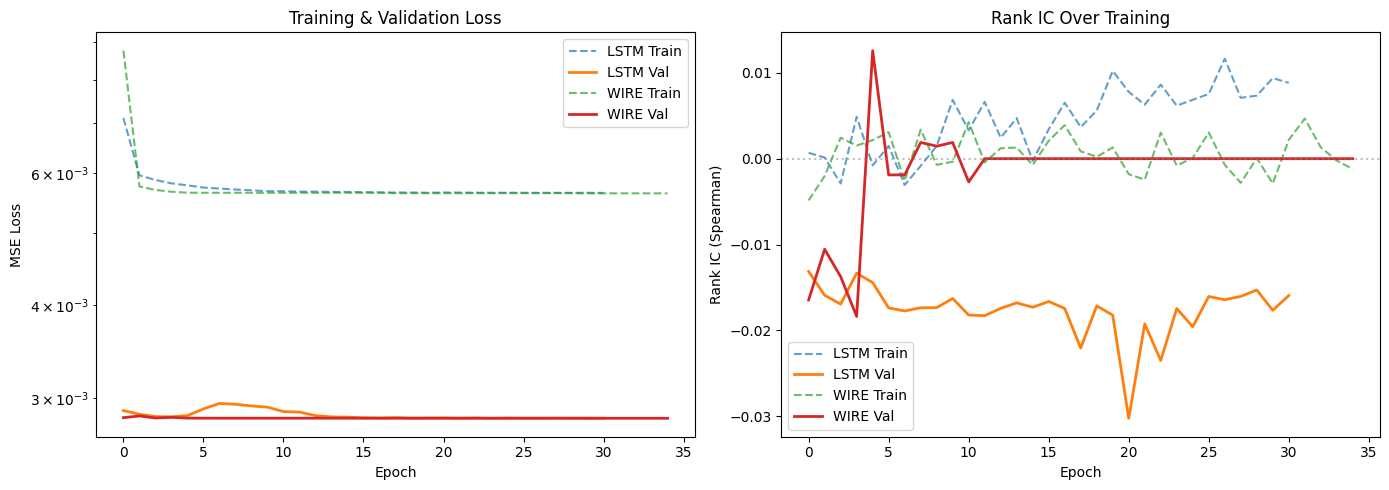


TEST SET RESULTS
Model                       MSE Loss    Rank IC
--------------------------------------------------
Baseline LSTM               0.003467    -0.0046
Graph Transformer+WIRE      0.003342    -0.0174


In [19]:
# --- 7.3 Comparison plots ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history_lstm["train_loss"], label="LSTM Train", linestyle="--", alpha=0.7)
axes[0].plot(history_lstm["val_loss"], label="LSTM Val", linewidth=2)
axes[0].plot(history_wire["train_loss"], label="WIRE Train", linestyle="--", alpha=0.7)
axes[0].plot(history_wire["val_loss"], label="WIRE Val", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].set_yscale("log")

# Rank IC curves
axes[1].plot(history_lstm["train_ic"], label="LSTM Train", linestyle="--", alpha=0.7)
axes[1].plot(history_lstm["val_ic"], label="LSTM Val", linewidth=2)
axes[1].plot(history_wire["train_ic"], label="WIRE Train", linestyle="--", alpha=0.7)
axes[1].plot(history_wire["val_ic"], label="WIRE Val", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Rank IC (Spearman)")
axes[1].set_title("Rank IC Over Training")
axes[1].legend()
axes[1].axhline(0, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

# Test set evaluation
test_loss_lstm, test_ic_lstm = evaluate(model_lstm, test_loader, model_type="lstm")
test_loss_wire, test_ic_wire = evaluate(model_wire, test_loader, sc_tensor, model_type="wire")

print(f"\n{'='*50}")
print(f"TEST SET RESULTS")
print(f"{'='*50}")
print(f"{'Model':<25} {'MSE Loss':>10} {'Rank IC':>10}")
print(f"{'-'*50}")
print(f"{'Baseline LSTM':<25} {test_loss_lstm:>10.6f} {test_ic_lstm:>10.4f}")
print(f"{'Graph Transformer+WIRE':<25} {test_loss_wire:>10.6f} {test_ic_wire:>10.4f}")

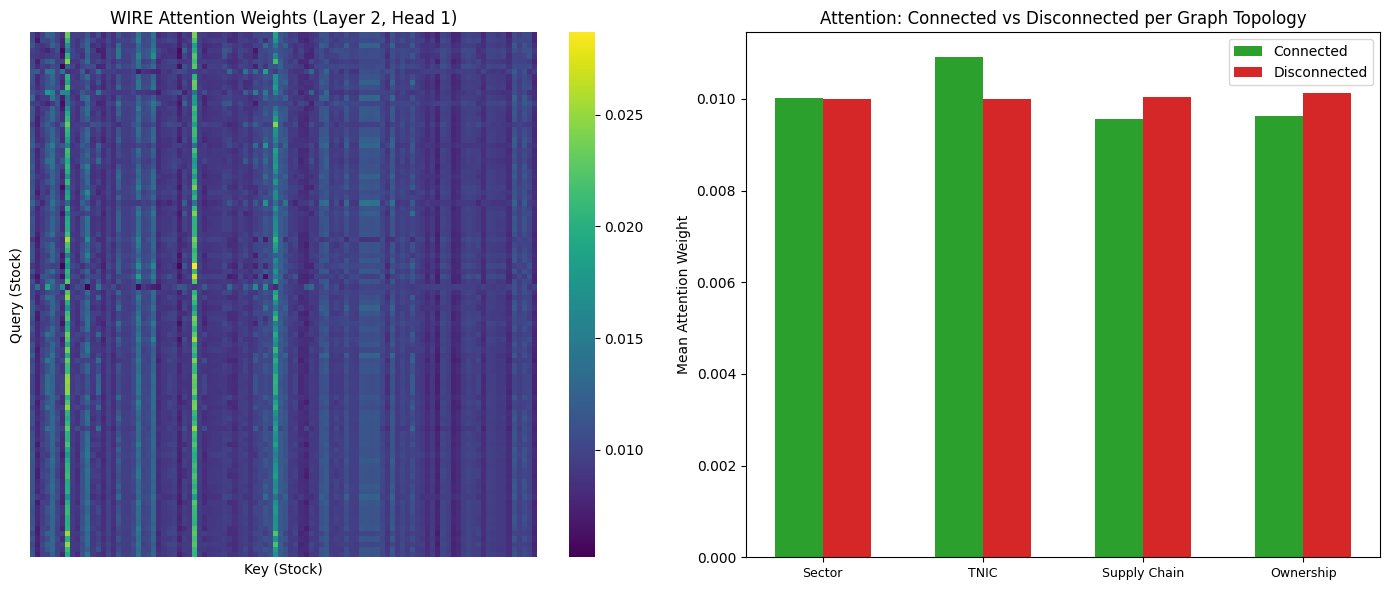


Topology                Connected   Disconnected    Ratio
--------------------------------------------------------
Sector                   0.010017       0.010007     1.00x
TNIC                     0.010906       0.009995     1.09x
Supply Chain             0.009564       0.010037     0.95x
Ownership                0.009634       0.010123     0.95x


In [20]:
# --- 7.4 Attention weight visualization (multi-relational) ---
# Inspect how WIRE shapes cross-stock attention across different topologies

model_wire.eval()
with torch.no_grad():
    sample_x, sample_y = test_ds[0]
    sample_x = sample_x.unsqueeze(0).to(device)
    _, attn_maps = model_wire(sample_x, sc_tensor)

# Plot attention from last layer, first head
attn = attn_maps[-1][0, 0].cpu().numpy()  # (N, N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full attention heatmap
sns.heatmap(attn, cmap="viridis", xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title("WIRE Attention Weights (Layer 2, Head 1)")
axes[0].set_xlabel("Key (Stock)")
axes[0].set_ylabel("Query (Stock)")

# Per-topology attention analysis
graph_dict = {"Sector": A_sector, "TNIC": A_tnic, "Supply Chain": A_supply, "Ownership": A_ownership}
means_connected, means_disconnected = [], []
labels = []

for name, A in graph_dict.items():
    conn_attn = attn[A > 0].mean() if (A > 0).any() else 0
    disc_attn = attn[(A == 0) & ~np.eye(N_STOCKS, dtype=bool)].mean()
    means_connected.append(conn_attn)
    means_disconnected.append(disc_attn)
    labels.append(name)

x_pos = np.arange(len(labels))
axes[1].bar(x_pos - 0.15, means_connected, 0.3, label="Connected", color="#2ca02c")
axes[1].bar(x_pos + 0.15, means_disconnected, 0.3, label="Disconnected", color="#d62728")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel("Mean Attention Weight")
axes[1].set_title("Attention: Connected vs Disconnected per Graph Topology")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Topology':<20} {'Connected':>12} {'Disconnected':>14} {'Ratio':>8}")
print("-" * 56)
for name, mc, md in zip(labels, means_connected, means_disconnected):
    ratio = mc / md if md > 0 else float('inf')
    print(f"{name:<20} {mc:>12.6f} {md:>14.6f} {ratio:>8.2f}x")

<a id="8-next"></a>
## 8. Next Steps

### Completed (Prototype)
- [x] Dataset acquisition: CRSP daily OHLCV + Compustat fundamentals (2015–2025)
- [x] Feature engineering: normalized OHLCV with sliding-window dataset
- [x] Sector graph construction via GICS codes + Laplacian spectral coordinates
- [x] Baseline LSTM implementation and training
- [x] WIRE implementation (Reid et al., 2024, Algorithm 1)
- [x] Graph Transformer with WIRE-enhanced attention
- [x] Evaluation framework: MSE + Rank IC
- [x] Attention weight interpretability analysis

### Planned Extensions
- [ ] DGT Baseline: Stanford CS224W Differential Graph Transformer (Pearson correlation edges)
- [ ] Multi-relational graphs: Competitor (TNIC), Supply Chain, Ownership (13F)
- [ ] Late Fusion: multi-topology super-coordinates for WIRE
- [ ] Ablation studies per topology
- [ ] Regime-specific evaluation (COVID crash, 2022 rate hikes)
- [ ] Fama-French market-neutral alpha